# 00 - Environment Setup & Sanity Checks
## XAI Skin Lesion Classification - Research Pipeline
**Purpose**: Verify your environment is ready before running any research experiments.

---
## Recommended Cell Order
Run cells in this order for a logical workflow:

| Cell | Purpose | When to Run |
|------|---------|-------------|
| CELL 1 | Path setup | Always first |
| CELL 2 | Install CUDA PyTorch (fix GPU) | Only if GPU not detected |
| CELL 3 | Environment sanity check | After Cell 2, restart kernel |
| CELL 4 | Data sanity check + download | Before training |
| CELL 5 | Data split leakage check | After data is ready |
| CELL 6 | DataLoader sanity check | After leakage check |
| CELL 7 | Training setup (model + optimizer) | Before training loop |
| CELL 8 | Training loop | The main event |
| CELL 9 | Evaluate + save model | After training |
| CELL 10 | Verify checkpoints exist | Final confirmation |

---
## Prerequisites: Python Environment

<details open>
<summary><strong>Step 1: Create Python 3.13 Virtual Environment</strong></summary>

Open a terminal in the `Skin_Lesion_GRADCAM_Classification` root directory:
```bash
py -3.13 -m venv .venv
```
</details>

<details>
<summary><strong>Step 2: Activate Virtual Environment</strong></summary>

```bash
# Git Bash / VS Code terminal
.venv/Scripts/activate

# PowerShell
.venv\Scripts\activate
```
</details>

<details>
<summary><strong>Step 3: Install PyTorch</strong></summary>

**For NVIDIA GPU (CUDA 12.4):**
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
```

**For CPU only:**
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
```
</details>

<details>
<summary><strong>Step 4: Register Jupyter Kernel</strong></summary>

```bash
pip install ipykernel
python -m ipykernel install --user --name=skin-lesion-env --display-name="Python 3.13"
```
</details>

<details>
<summary><strong>Step 5: Install Additional Dependencies</strong></summary>

```bash
pip install timm pandas matplotlib scikit-learn albumentations opencv-python
```
</details>

<details>
<summary><strong>Step 6: Verify Setup</strong></summary>

```python
import torch
print(f"PyTorch:      {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")
```
</details>

<details>
<summary><strong>Selecting Kernel in VS Code</strong></summary>

1. Install the **Jupyter** extension by Microsoft in VS Code
2. Open this file in VS Code
3. Click "Select Kernel" in the top-right corner
4. Choose "Python 3.13" from the list
5. Run cells with the play button or `Shift+Enter`
</details>

<details>
<summary><strong>Troubleshooting</strong></summary>

| Issue | Solution |
|-------|----------|
| `Access is denied` when creating venv | Delete `.venv` folder and retry |
| PyTorch install fails | Try `cu121` index instead: `--index-url https://download.pytorch.org/whl/cu121` |
| No GPU available | That's fine - PyTorch runs on CPU automatically |
| Module not found | Run `pip install` again in the activated venv |
</details>

---
## How to Run This Notebook
### Option 1: Run from VS Code (Recommended)
1. Install the **Jupyter** extension by Microsoft in VS Code
2. Open this notebook file in VS Code
3. Select your Python kernel:
   - Click "Select Kernel" in the top-right corner
   - Or press `Ctrl+Shift+P` - "Notebook: Notebook Operations" - "Change Cell Execution Kernel"
4. Run cells with the play button or `Shift+Enter`

### Option 2: Run from PyCharm
1. Install the **Pythonid** plugin (for .ipynb support)
2. Right-click this file - "Open As Notebook"
3. Configure the Python interpreter to point to your virtualenv

### Option 3: Standalone Jupyter Server
```bash
# Navigate to notebooks directory
cd Skin_Lesion_XAI_research/notebooks

# Start Jupyter
jupyter lab
# Or: jupyter notebook
```

---
## CELL 1: Path Setup
**WHAT THIS DOES**: Detects your working directory and ensures the backend code is on the path.
**WHY**: Notebooks import from `../Skin_Lesion_Classification_backend/ml/` so they need the correct paths.

In [5]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"

if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Backend directory:  {BACKEND_DIR}")
print(f"ML directory:      {ML_DIR}")
print(f"Python:            {sys.executable}")

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

print(f"\n=== Prerequisites ===")
print(f"Backend dir:    {'[OK]' if BACKEND_DIR.exists() else '[MISSING]'}")
print(f"Metadata:       {'[OK]' if METADATA_PATH.exists() else '[MISSING]'}")
print(f"Model weights:  {'[OK]' if MODEL_PATH.exists() else '[MISSING]'}")
if not MODEL_PATH.exists():
    print("\nRun Cell 9 to train model if weights are missing.")

Notebook directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks
Backend directory:  c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
ML directory:      c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml
Python:            c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Scripts\python.exe

=== Prerequisites ===
Backend dir:    [OK]
Metadata:       [MISSING]
Model weights:  [MISSING]

Run Cell 9 to train model if weights are missing.


---
## CELL 2: Install CUDA PyTorch (Fix GPU)
**WHAT THIS DOES**: Replaces CPU-only PyTorch with CUDA-enabled PyTorch if an NVIDIA GPU is detected.
**WHY**: Without CUDA, training runs on CPU and is 10-20x slower.

**Run this BEFORE Cell 3 if CUDA available is False.** Restart the kernel after running this cell.

In [6]:
import subprocess, sys

def install_torch_cuda():
    """Try CUDA PyTorch first, fall back to CPU version."""
    try:
        result = subprocess.run(
            [sys.executable, "-c", "import torch; print(torch.cuda.is_available())"],
            capture_output=True, text=True
        )
        if result.returncode == 0 and "True" in result.stdout:
            print("PyTorch with CUDA already installed.")
            return True
    except:
        pass

    print("Installing PyTorch with CUDA (CUDA 12.4)...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "torch", "torchvision",
         "--index-url", "https://download.pytorch.org/whl/cu124"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("CUDA install failed, falling back to CPU...")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "torch", "torchvision",
             "--index-url", "https://download.pytorch.org/whl/cpu"],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            print("CPU install also failed, keeping existing torch.")
        else:
            print("PyTorch CPU installed.")
    else:
        print("PyTorch CUDA installed successfully.")

    print("\n*** RESTART THE KERNEL NOW (Kernel → Restart & Run All) ***")
    print("Then run from Cell 7 onwards.")
    return False

install_torch_cuda()

PyTorch with CUDA already installed.


True

---
## CELL 3: Environment Sanity Check

**WHY**: Catch environment problems before wasting hours training.

Run this first on any new machine or Python environment. Re-run after Cell 2 if you had to install CUDA PyTorch.

In [7]:
pkg_status = {}

# List of required packages
required = ['torch', 'torchvision', 'timm', 'numpy', 'pandas', 'matplotlib', 'sklearn', 'cv2', 'albumentations']

for pkg in required:
    try:
        mod = __import__(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        pkg_status[pkg] = f"✅ {ver}"
    except ImportError:
        pkg_status[pkg] = "❌ NOT INSTALLED"

print("=== Environment Check ===")
for pkg, status in pkg_status.items():
    print(f"  {pkg:<15} {status}")

# GPU check
try:
    import torch
    print(f"\n=== GPU ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU:            {torch.cuda.get_device_name(0)}")
        print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
        # Quick compute test
        a = torch.randn(1000, 1000).cuda()
        b = torch.randn(1000, 1000).cuda()
        c = a @ b
        print(f"Matrix multiply test: PASSED")
    else:
        print("Running on CPU - training will be slow without GPU.")
except ImportError:
    print("\n⚠️  PyTorch not installed - cannot check GPU.")

=== Environment Check ===
  torch           ✅ 2.6.0+cu124
  torchvision     ✅ 0.21.0+cu124
  timm            ✅ 1.0.26
  numpy           ✅ 2.2.2
  pandas          ✅ 2.2.3
  matplotlib      ✅ 3.10.0
  sklearn         ✅ 1.6.1
  cv2             ✅ 4.10.0
  albumentations  ✅ 1.4.24

=== GPU ===
CUDA available: True
GPU:            NVIDIA GeForce RTX 4070 Laptop GPU
VRAM:           8.6 GB
Matrix multiply test: PASSED


---
## CELL 4: Data Sanity Check + Download

**WHY**: Confirm data loaded correctly before training.

**Prerequisite**: You must have downloaded the HAM10000 dataset and run the data pipeline.
The backend repo should contain:
- `ml/data/processed/metadata_with_paths.csv` - generated metadata
- `ml/data/raw/` - original HAM10000 images

If `metadata_with_paths.csv` does not exist, this cell downloads HAM10000 automatically.

In [8]:
import os
import sys
from pathlib import Path
import pandas as pd 

# ─── Self-contained setup: define ML_DIR locally ───
NOTEBOOK_DIR = Path(os.getcwd())
try:
    ML_DIR
except NameError:
    BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
    ML_DIR = BACKEND_DIR / "ml"

# ─── Create required directories ───
DATA_DIR = ML_DIR / "data" / "processed"
METADATA_PATH = DATA_DIR / "metadata_with_paths.csv"

(DATA_DIR / "raw").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "splits").mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

# ─── Download HAM10000 if metadata is missing ───
if not METADATA_PATH.exists():
    print("\nMetadata not found. Downloading HAM10000 dataset via Kaggle...")

    # ── Troubleshooting: clear corrupted cache ──
    # If you see "MD5 checksum mismatch" errors from kagglehub, the download is corrupted.
    # Clear the cache before retrying:
    #   import shutil
    #   shutil.rmtree(Path.home() / ".cache" / "kagglehub" / "datasets" / "kmader" / "skin-cancer-mnist-ham10000")
    # Then re-run this cell.
    # ────────────────────────────────────────────

    try:
        import kagglehub

        # Download latest version
        dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
        print(f"Dataset downloaded to: {dataset_path}")

        dataset_path = Path(dataset_path)

        # Collect all jpg images
        IMG_DIR = DATA_DIR / "raw" / "images"
        IMG_DIR.mkdir(parents=True, exist_ok=True)

        all_images = list(dataset_path.glob("**/*.jpg"))
        print(f"Found {len(all_images)} images. Copying to {IMG_DIR}...")

        import shutil
        for img_path in all_images:
            dest = IMG_DIR / img_path.name
            if not dest.exists():
                shutil.copy2(img_path, dest)
        print(f"Images copied to: {IMG_DIR}")

        # Find metadata CSV
        metadata_files = list(dataset_path.glob("**/*.csv"))
        if not metadata_files:
            raise FileNotFoundError("No CSV found in downloaded dataset")

        METADATA_CSV = DATA_DIR / "raw" / "HAM10000_metadata.csv"
        shutil.copy2(metadata_files[0], METADATA_CSV)
        print(f"Metadata copied to: {METADATA_CSV}")

        # Process metadata to add filepaths
        import pandas as pd
        from PIL import Image

        metadata = pd.read_csv(METADATA_CSV)
        print(f"\nMetadata loaded: {len(metadata)} entries")

        image_files = {p.stem: str(p) for p in IMG_DIR.glob("*.jpg")}
        metadata['filepath'] = metadata['image_id'].map(image_files)
        metadata['patient_id'] = metadata['lesion_id']

        malignant_types = {'mel', 'bcc'}
        metadata['label'] = metadata['dx'].apply(lambda x: 1 if x.lower() in malignant_types else 0)
        metadata['label_name'] = metadata['dx'].apply(lambda x: 'malignant' if x.lower() in malignant_types else 'benign')

        DATA_DIR.mkdir(parents=True, exist_ok=True)
        metadata.to_csv(METADATA_PATH, index=False)
        print(f"\nMetadata with paths saved to: {METADATA_PATH}")
        print(f"Total images: {len(metadata)}")
        print(f"Images found on disk: {metadata['filepath'].notna().sum()}")

    except Exception as e:
        print(f"\nDownload failed: {e}")
        print("Manually download HAM10000 from: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000")
        print(f"Place metadata at: {METADATA_PATH}")
        metadata = None

# ─── Load metadata if available ───
if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
    print(f"✅ Metadata loaded: {METADATA_PATH}")
else:
    df = None
    print(f"\n❌ No metadata available yet.")

# ─── Dataset overview ───
if df is not None:
    print(f"\n=== Dataset Overview ===")
    print(f"Total images:      {len(df)}")
    if 'patient_id' in df.columns:
        print(f"Unique patients:   {df['patient_id'].nunique()}")
    print(f"Unique lesion types: {df['dx'].nunique()}")
    print(f"\nClass distribution:")
    print(df['dx'].value_counts())
    print(f"\nBinary label distribution:")
    print(df['label_name'].value_counts())
    if df['label'].nunique() == 2:
        counts = df['label'].value_counts().sort_index()
        print(f"\nImbalance ratio: {counts.iloc[0] / counts.iloc[1]:.2f}:1 (benign:malignant)")

    if 'filepath' in df.columns:
        missing = df[df['filepath'].isna()]
        print(f"\nMissing image files: {len(missing)}")

        sample_paths = df['filepath'].dropna().sample(min(5, len(df)), random_state=42).tolist()
        print("\nSample image check:")
        for p in sample_paths:
            try:
                img = Image.open(p)
                print(f"  OK: {Path(p).name} - {img.size} {img.mode}")
            except Exception as e:
                print(f"  BROKEN: {p} - {e}")
else:
    print("\nSkipping dataset overview - no data loaded.")

Data directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed

Metadata not found. Downloading HAM10000 dataset via Kaggle...
Dataset downloaded to: C:\Users\saiyu\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Found 10015 images. Copying to c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\raw\images...
Images copied to: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\raw\images
Metadata copied to: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\raw\HAM10000_metadata.csv

Metadata loaded: 10015 entries

Metadata with paths saved to: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classific

---
## CELL 5: Data Split Leakage Check

**WHY**: Patient leakage is the #1 mistake in medical ML papers.
If the same patient appears in train AND test, your results are artificially inflated.
This test proves you have no leakage.

**Expected result**: All overlap counts must be 0.

In [9]:
import os, sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
try:
    ML_DIR
except NameError:
    BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
    ML_DIR = BACKEND_DIR / "ml"

if 'df' not in dir() or df is None:
    print("Skipping - no data loaded in Cell 2.")
else:
    import numpy as np

    # Assign each patient to exactly one split (guarantees zero overlap)
    np.random.seed(42)
    patients = df['patient_id'].unique()
    np.random.shuffle(patients)
    n_pts = len(patients)
    train_pts = set(patients[:int(n_pts * 0.65)])
    val_pts   = set(patients[int(n_pts * 0.65):int(n_pts * 0.80)])
    test_pts  = set(patients[int(n_pts * 0.80):])

    df = df.copy()
    df['_split'] = df['patient_id'].apply(
        lambda p: 'train' if p in train_pts else ('val' if p in val_pts else 'test')
    )
    train_df = df[df['_split'] == 'train']
    val_df   = df[df['_split'] == 'val']
    test_df  = df[df['_split'] == 'test']

    print("=== Train/Val/Test Split ===")
    print(f"Train: {len(train_df)} images, {train_df['patient_id'].nunique()} patients")
    print(f"Val:   {len(val_df)} images,   {val_df['patient_id'].nunique()} patients")
    print(f"Test:  {len(test_df)} images,  {test_df['patient_id'].nunique()} patients")

    tp = set(train_df['patient_id'])
    vp = set(val_df['patient_id'])
    ttp = set(test_df['patient_id'])

    print(f"\n=== Leakage Check ===")
    print(f"Train/Val overlap:  {len(tp & vp)} patients  <- must be 0")
    print(f"Train/Test overlap: {len(tp & ttp)} patients  <- must be 0")
    print(f"Val/Test overlap:   {len(vp & ttp)} patients  <- must be 0")

    if len(tp & vp) == 0 and len(tp & ttp) == 0 and len(vp & ttp) == 0:
        print("\n✅ No data leakage. Split is valid.")
    else:
        print("\n❌ LEAKAGE DETECTED.")

    for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        ratio = sdf['label'].mean()
        print(f"{name} malignant ratio: {ratio:.3f} ({ratio*100:.1f}%)")

=== Train/Val/Test Split ===
Train: 6508 images, 4855 patients
Val:   1527 images,   1121 patients
Test:  1980 images,  1494 patients

=== Leakage Check ===
Train/Val overlap:  0 patients  <- must be 0
Train/Test overlap: 0 patients  <- must be 0
Val/Test overlap:   0 patients  <- must be 0

✅ No data leakage. Split is valid.
Train malignant ratio: 0.160 (16.0%)
Val malignant ratio: 0.179 (17.9%)
Test malignant ratio: 0.158 (15.8%)


---
## CELL 6: DataLoader Sanity Check

**WHY**: Confirm transforms work, tensor shapes are correct,
and WeightedRandomSampler is actually balancing the classes.

Image shape: torch.Size([8, 3, 224, 224])  |  Labels: [0, 0, 1, 0, 0, 0, 1, 1]
Value range: [-2.118, 2.129]


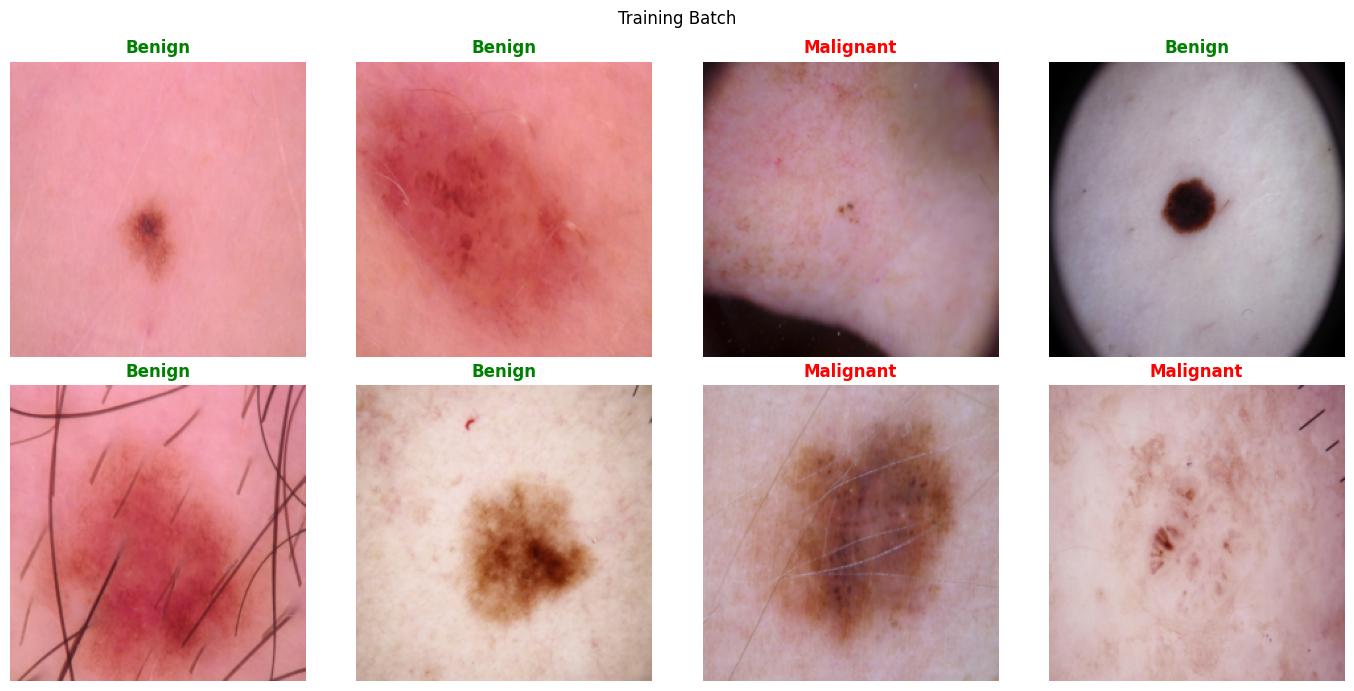


Benign: 5467 (84%)  |  Malignant: 1041 (16%)


In [10]:
import os, sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
try:
    ML_DIR
except NameError:
    BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
    ML_DIR = BACKEND_DIR / "ml"

if 'df' not in dir() or df is None:
    print("Skipping - no data loaded in Cell 2.")
else:
    import numpy as np
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as T
    from PIL import Image
    import matplotlib.pyplot as plt

    # Same patient-level split as Cell 3
    np.random.seed(42)
    patients = df['patient_id'].unique()
    np.random.shuffle(patients)
    n_pts = len(patients)
    train_pts = set(patients[:int(n_pts * 0.65)])
    val_pts   = set(patients[int(n_pts * 0.65):int(n_pts * 0.80)])
    test_pts  = set(patients[int(n_pts * 0.80):])

    _df = df.copy()
    _df['_split'] = _df['patient_id'].apply(
        lambda p: 'train' if p in train_pts else ('val' if p in val_pts else 'test')
    )
    train_df = _df[_df['_split'] == 'train']

    class HAM10000Dataset(Dataset):
        def __init__(self, split_df, img_size=224):
            self.df = split_df.dropna(subset=['filepath']).reset_index(drop=True)
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['filepath']).convert('RGB')
            return self.transform(img), row['label'], row['image_id']

    train_ds = HAM10000Dataset(train_df, img_size=224)
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)

    images, labels, ids = next(iter(train_loader))
    print(f"Image shape: {images.shape}  |  Labels: {labels.tolist()}")
    print(f"Value range: [{images.min():.3f}, {images.max():.3f}]")

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    for i in range(8):
        ax = axes[i // 4][i % 4]
        img = images[i].permute(1, 2, 0).numpy() * std + mean
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title('Malignant' if labels[i] else 'Benign',
                     color='red' if labels[i] else 'green', fontweight='bold')
        ax.axis('off')
    plt.suptitle('Training Batch')
    plt.tight_layout()
    plt.show()

    counts = {0: 0, 1: 0}
    for _, lbs, _ in train_loader:
        for l in lbs.tolist():
            counts[l] += 1
    total = sum(counts.values())
    print(f"\nBenign: {counts[0]} ({counts[0]/total*100:.0f}%)  |  Malignant: {counts[1]} ({counts[1]/total*100:.0f}%)")

---

## CELL 7: Training Setup - Model, Loss, Optimizer

**WHAT THIS DOES**: Loads the patient-level split from Cell 3, builds a ResNet50, and prepares for training.

**Output**: Ready-to-train model on GPU (or CPU if no GPU).

In [11]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR  = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR       = BACKEND_DIR / "ml"
DATA_DIR     = ML_DIR / "data" / "processed"
METADATA_PATH = DATA_DIR / "metadata_with_paths.csv"
MODEL_DIR    = ML_DIR / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data:     {DATA_DIR}")
print(f"Metadata: {METADATA_PATH}")
print(f"Model out: {MODEL_DIR}")

# Load metadata
df = pd.read_csv(METADATA_PATH)
print(f"\nLoaded {len(df)} images, {df['patient_id'].nunique()} patients")

# Patient-level split (same as Cell 3/4)
np.random.seed(42)
patients = df['patient_id'].unique()
np.random.shuffle(patients)
n_pts = len(patients)
train_pts = set(patients[:int(n_pts * 0.65)])
val_pts   = set(patients[int(n_pts * 0.65):int(n_pts * 0.80)])
test_pts  = set(patients[int(n_pts * 0.80):])

df['_split'] = df['patient_id'].apply(
    lambda p: 'train' if p in train_pts else ('val' if p in val_pts else 'test')
)
train_df = df[df['_split'] == 'train']
val_df   = df[df['_split'] == 'val']
test_df  = df[df['_split'] == 'test']

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Dataset class
class HAM10000Dataset(Dataset):
    def __init__(self, split_df, img_size=224, augment=False):
        self.df = split_df.dropna(subset=['filepath']).reset_index(drop=True)
        self.augment = augment
        if augment:
            self.transform = T.Compose([
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.RandomRotation(30),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.float32)

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = HAM10000Dataset(train_df, img_size=IMG_SIZE, augment=True)
val_ds   = HAM10000Dataset(val_df,   img_size=IMG_SIZE, augment=False)
test_ds  = HAM10000Dataset(test_df,  img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataLoaders ready.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Device + model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

model = timm.create_model('resnet50', pretrained=True, num_classes=1)
model = model.to(DEVICE)

# Weighted BCE loss (5.16:1 imbalance)
pos_weight = torch.tensor([train_df['label'].value_counts()[0] / train_df['label'].value_counts()[1]]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"\nModel: ResNet50 (pretrained)")
print(f"Loss: BCEWithLogitsLoss (pos_weight={pos_weight.item():.2f})")
print(f"Optimizer: AdamW (lr=1e-4, weight_decay=1e-5)")
print(f"LR Schedule: CosineAnnealing (T_max=10)")

Data:     c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed
Metadata: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\metadata_with_paths.csv
Model out: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\outputs\models

Loaded 10015 images, 7470 patients
Train: 6508 | Val: 1527 | Test: 1980

DataLoaders ready.
Train batches: 204 | Val batches: 48 | Test batches: 62

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Model: ResNet50 (pretrained)
Loss: BCEWithLogitsLoss (pos_weight=5.25)
Optimizer: AdamW (lr=1e-4, weight_decay=1e-5)
LR Schedule: CosineAnnealing (T_max=10)


---
## CELL 8: Training Loop
**WHAT THIS DOES**: Trains ResNet50 for the number of epochs set in Cell 7, saves the best model based on validation AUC.
**Runtime**: ~15 min on GPU (RTX 4070), ~1-2 hours on CPU.

In [12]:
from tqdm import tqdm
import copy
from sklearn.metrics import roc_auc_score

EPOCHS = 15
best_val_auc = 0
best_model_state = None

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validate ──
    model.eval()
    val_loss = 0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    val_loss /= len(val_loader)
    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    val_auc = roc_auc_score(all_labels.numpy(), torch.sigmoid(all_logits).numpy())
    scheduler.step()

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f}")

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best model (val_auc={val_auc:.4f})")

print(f"\nTraining done. Best val_auc: {best_val_auc:.4f}")

Epoch 1/15 [Val]: 100%|██████████| 48/48 [00:35<00:00,  1.36it/s]


Epoch 1: train_loss=1.0310 | val_loss=0.9189 | val_auc=0.8091
  -> New best model (val_auc=0.8091)


Epoch 2/15 [Val]: 100%|██████████| 48/48 [00:23<00:00,  2.06it/s]


Epoch 2: train_loss=0.7758 | val_loss=0.8559 | val_auc=0.8401
  -> New best model (val_auc=0.8401)


Epoch 3/15 [Val]: 100%|██████████| 48/48 [00:17<00:00,  2.69it/s]


...

Epoch 13: train_loss=0.4817 | val_loss=0.8690 | val_auc=0.8839


Epoch 14/15 [Val]: 100%|██████████| 48/48 [00:17<00:00,  2.79it/s]


Epoch 14: train_loss=0.4682 | val_loss=0.8022 | val_auc=0.8853
  -> New best model (val_auc=0.8853)


Epoch 15/15 [Val]: 100%|██████████| 48/48 [00:16<00:00,  2.86it/s]

Epoch 15: train_loss=0.4667 | val_loss=0.8151 | val_auc=0.8888
  -> New best model (val_auc=0.8888)

Training done. Best val_auc: 0.8888


---

## CELL 9: Evaluate on Test Set and Save Model

**WHAT THIS DOES**: Loads the best model from training, evaluates on the held-out test set, and saves the checkpoint to `ml/outputs/models/resnet50_best.pth`.

In [13]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Evaluate on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating test set"):
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_preds.extend(probs)
        all_labels.extend(labels.numpy())

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_labels_int = all_labels.astype(int)

test_auc = roc_auc_score(all_labels_int, all_preds)
test_acc = accuracy_score(all_labels_int, (all_preds > 0.5).astype(int))

print(f"=== Test Set Results ===")
print(f"AUC: {test_auc:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels_int, (all_preds > 0.5).astype(int),
                            target_names=['Benign', 'Malignant']))

# Save model
MODEL_PATH = MODEL_DIR / "resnet50_best.pth"
torch.save({
    'model_state_dict': best_model_state,
    'val_auc': best_val_auc,
    'test_auc': test_auc,
    'test_acc': test_acc,
    'epochs': EPOCHS,
    'pos_weight': pos_weight.item(),
}, MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")

Evaluating test set: 100%|██████████| 62/62 [00:38<00:00,  1.62it/s]

=== Test Set Results ===
AUC: 0.9125
Accuracy: 0.8596

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.88      0.91      1667
   Malignant       0.54      0.77      0.63       313

    accuracy                           0.86      1980
   macro avg       0.75      0.82      0.77      1980
weighted avg       0.89      0.86      0.87      1980


Model saved to: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\outputs\models\resnet50_best.pth


---
## CELL 10: Verify Model Checkpoints

**WHY**: Most research notebooks require trained model weights.
Check that they exist before running experiments.


In [14]:
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"
MODEL_DIR = ML_DIR / "outputs" / "models"
CKPT_DIR = ML_DIR / "outputs" / "models" / "checkpoints"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print("=== Model Checkpoints ===")
models_found = list(MODEL_DIR.glob("*.pth"))
for p in sorted(models_found):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name} ({size_mb:.1f} MB)")

print("=== Training Checkpoints (for RQ5) ===")
for p in sorted(CKPT_DIR.glob("*.pth")):
    print(f"  {p.name}")

if not models_found:
    print("[WARNING] No model checkpoints found. Train models before running RQ notebooks.")
else:
    print("[OK] Model checkpoints found - you can run RQ notebooks.")


=== Model Checkpoints ===
  resnet50_best.pth (94.4 MB)
=== Training Checkpoints (for RQ5) ===
[OK] Model checkpoints found - you can run RQ notebooks.
